In [1]:
!pip install yfinance

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 279.8 kB/s eta 0:00:06
   ---------- ----------------------------- 0.5/2.0 MB 279.8 kB/s eta 0:00:06
   ---------- ----------------------------- 0.5/2.0 MB 279.8 kB/s eta 0:00:06
   ---------- ----------------------------- 0.5/2.0 MB 279.8 kB/s eta 0:00:0

  You can safely remove it manually.


In [2]:
import yfinance as yf

aapl = yf.download("AAPL", start="2020-01-01", end="2026-08-11")

[*********************100%***********************]  1 of 1 completed


In [3]:
aapl.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.271523,72.331679,71.029900,71.282553,135480400
2020-01-03,71.568924,72.326889,71.345145,71.501549,146322800
2020-01-06,72.139191,72.177691,70.442792,70.693043,118387200
2020-01-07,71.799919,72.403881,71.580950,72.148820,108872000
2020-01-08,72.954895,73.255675,71.503931,71.503931,132079200


In [4]:
aapl.shape

(1659, 5)

In [5]:
aapl.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1659 entries, 2020-01-02 to 2026-08-10
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1659 non-null   float64
 1   (High, AAPL)    1659 non-null   float64
 2   (Low, AAPL)     1659 non-null   float64
 3   (Open, AAPL)    1659 non-null   float64
 4   (Volume, AAPL)  1659 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 77.8 KB


In [6]:
aapl.index.duplicated().sum()

0

In [7]:
aapl.index.min(), aapl.index.max()

(Timestamp('2020-01-02 00:00:00'), Timestamp('2026-08-10 00:00:00'))

In [8]:
aapl.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1659.000000,1659.000000,1659.000000,1659.000000,1.659000e+03
mean,175.136054,176.936366,173.158448,174.955851,8.150571e+07
std,58.527194,58.974076,58.005063,58.438622,5.040877e+07
min,54.117027,55.113166,51.280570,55.011864,1.791060e+07
25%,135.701057,137.894277,133.720466,135.504405,4.877190e+07
50%,168.801971,170.381164,167.286274,168.572304,6.718000e+07
75%,218.915436,220.260219,215.596298,218.064573,9.658690e+07
max,339.786926,344.273097,337.059318,339.736982,4.265100e+08


In [9]:
aapl = aapl.sort_index()

aapl.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.271523,72.331679,71.029900,71.282553,135480400
2020-01-03,71.568924,72.326889,71.345145,71.501549,146322800
2020-01-06,72.139191,72.177691,70.442792,70.693043,118387200
2020-01-07,71.799919,72.403881,71.580950,72.148820,108872000
2020-01-08,72.954895,73.255675,71.503931,71.503931,132079200


In [10]:
aapl["Daily_Price_Change"] = aapl["Close"] - aapl["Close"].shift(1)

aapl[["Close", "Daily_Price_Change"]].head()

Price,Close,Daily_Price_Change
Ticker,AAPL,
Date,,
2020-01-02,72.271523,NaN
2020-01-03,71.568924,-0.702599
2020-01-06,72.139191,0.570267
2020-01-07,71.799919,-0.339272
2020-01-08,72.954895,1.154976


In [11]:
aapl["Percentage_Price_Change"] = aapl["Close"].pct_change() * 100

aapl[["Close", "Daily_Price_Change", "Percentage_Price_Change"]].head()

Price,Close,Daily_Price_Change,Percentage_Price_Change
Ticker,AAPL,,
Date,,,
2020-01-02,72.271523,NaN,NaN
2020-01-03,71.568924,-0.702599,-0.972165
2020-01-06,72.139191,0.570267,0.796808
2020-01-07,71.799919,-0.339272,-0.470301
2020-01-08,72.954895,1.154976,1.608603


In [12]:
aapl["MA_7"] = aapl["Close"].rolling(window=7).mean()

aapl[["Close", "MA_7"]].head(10)

Price,Close,MA_7
Ticker,AAPL,
Date,,
2020-01-02,72.271523,NaN
2020-01-03,71.568924,NaN
2020-01-06,72.139191,NaN
2020-01-07,71.799919,NaN
2020-01-08,72.954895,NaN
2020-01-09,74.504532,NaN
2020-01-10,74.672974,72.844565
2020-01-13,76.268295,73.415533


In [13]:
aapl["MA_30"] = aapl["Close"].rolling(window=30).mean()

aapl[["Close", "MA_7", "MA_30"]].tail()

Price,Close,MA_7,MA_30
Ticker,AAPL,,
Date,,,
2026-08-04,309.113403,324.051954,313.748076
2026-08-05,310.732025,320.353716,314.304264
2026-08-06,312.140808,316.404271,314.948044
2026-08-07,313.059998,312.855900,316.219614
2026-08-10,308.260010,309.301235,317.043765


In [15]:
aapl.columns = aapl.columns.get_level_values(0)

aapl.head()

Price,Close,High,Low,Open,Volume,Daily_Price_Change,Percentage_Price_Change,MA_7,MA_30
Date,,,,,,,,,
2020-01-02,72.271523,72.331679,71.029900,71.282553,135480400,NaN,NaN,NaN,NaN
2020-01-03,71.568924,72.326889,71.345145,71.501549,146322800,-0.702599,-0.972165,NaN,NaN
2020-01-06,72.139191,72.177691,70.442792,70.693043,118387200,0.570267,0.796808,NaN,NaN
2020-01-07,71.799919,72.403881,71.580950,72.148820,108872000,-0.339272,-0.470301,NaN,NaN
2020-01-08,72.954895,73.255675,71.503931,71.503931,132079200,1.154976,1.608603,NaN,NaN


In [16]:
monthly = aapl.resample("ME").agg({
    "Close": "last",
    "Volume": "sum"
})

monthly.head()

Price,Close,Volume
Date,,
2020-01-31,74.475670,2934370400
2020-02-29,65.933189,3019279200
2020-03-31,61.333603,6280072400
2020-04-30,70.863235,3265299200
2020-05-31,76.893288,2805936000


In [17]:
monthly["Monthly_Return"] = monthly["Close"].pct_change() * 100

monthly.head()

Price,Close,Volume,Monthly_Return
Date,,,
2020-01-31,74.475670,2934370400,NaN
2020-02-29,65.933189,3019279200,-11.470163
2020-03-31,61.333603,6280072400,-6.976132
2020-04-30,70.863235,3265299200,15.537376
2020-05-31,76.893288,2805936000,8.509423


In [18]:
daily_volatility = aapl["Percentage_Price_Change"].std()

daily_volatility

1.982293345030246

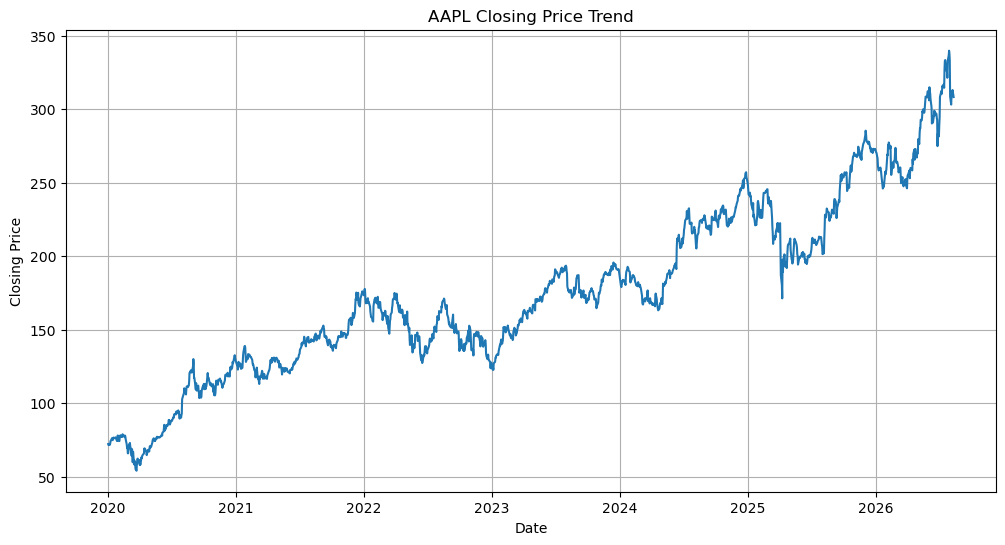

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(aapl.index, aapl["Close"])
plt.title("AAPL Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

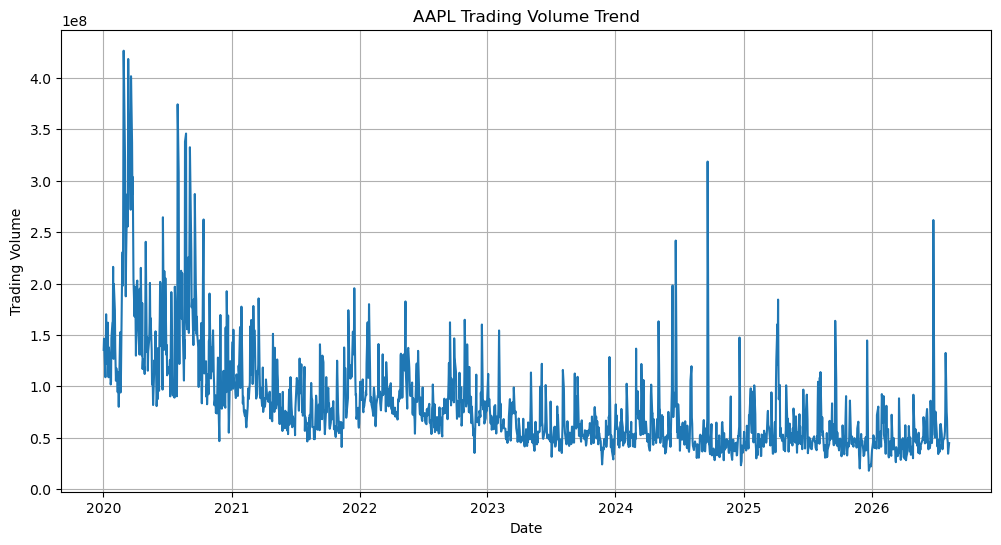

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(aapl.index, aapl["Volume"])
plt.title("AAPL Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Trading Volume")
plt.grid(True)
plt.show()

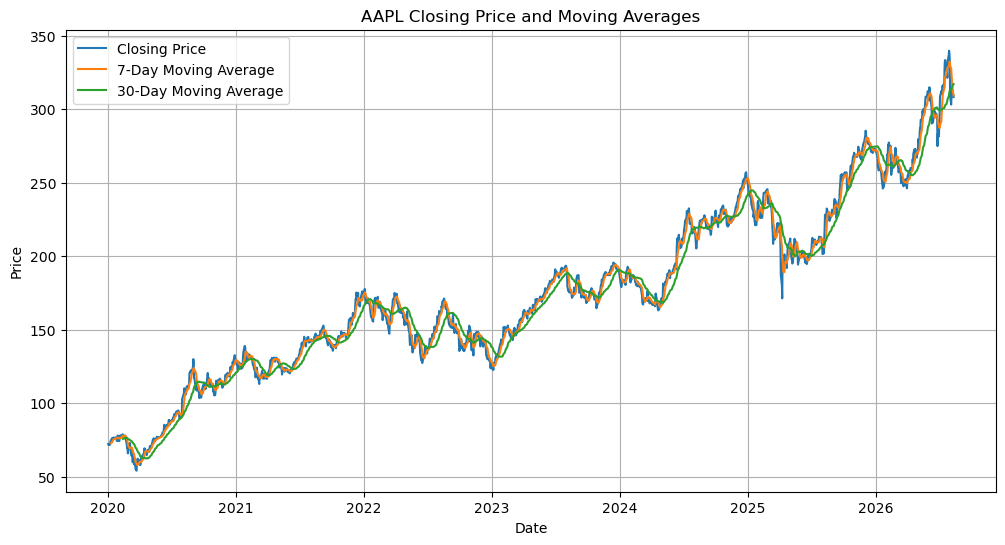

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(aapl.index, aapl["Close"], label="Closing Price")
plt.plot(aapl.index, aapl["MA_7"], label="7-Day Moving Average")
plt.plot(aapl.index, aapl["MA_30"], label="30-Day Moving Average")

plt.title("AAPL Closing Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

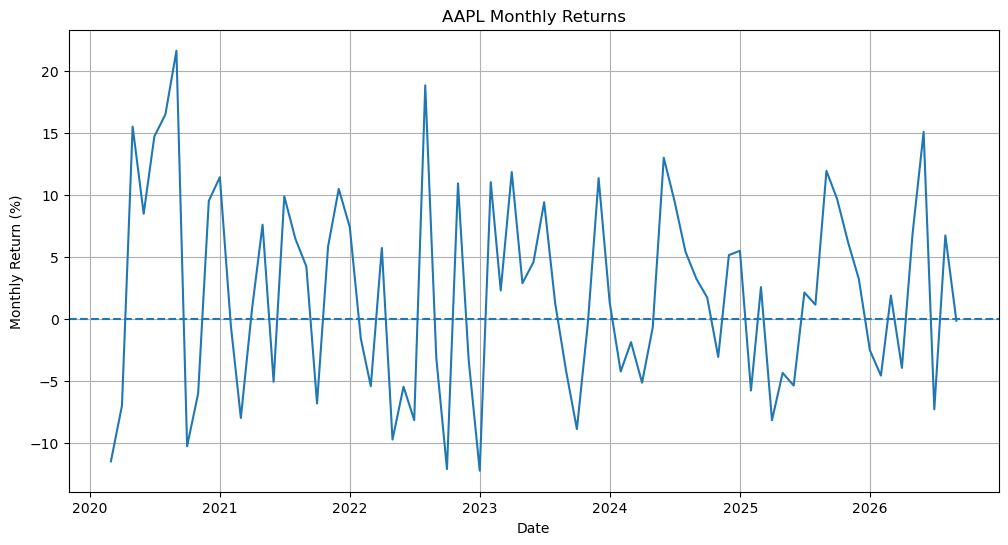

In [22]:
plt.figure(figsize=(12, 6))

plt.plot(monthly.index, monthly["Monthly_Return"])

plt.title("AAPL Monthly Returns")
plt.xlabel("Date")
plt.ylabel("Monthly Return (%)")
plt.axhline(0, linestyle="--")
plt.grid(True)
plt.show()

In [23]:
monthly["Monthly_Return"].nlargest(5)

Date
2020-08-31    21.656911
2022-07-31    18.863354
2020-07-31    16.513166
2020-04-30    15.537376
2026-05-31    15.108715
Name: Monthly_Return, dtype: float64

In [24]:
monthly["Monthly_Return"].nsmallest(5)

Date
2022-12-31   -12.227257
2022-09-30   -12.097692
2020-02-29   -11.470163
2020-09-30   -10.252624
2022-04-30    -9.713075
Name: Monthly_Return, dtype: float64

In [25]:
average_monthly_return = monthly["Monthly_Return"].mean()

average_monthly_return

2.120231913099983

In [26]:
start_price = aapl["Close"].iloc[0]
end_price = aapl["Close"].iloc[-1]

overall_return = ((end_price - start_price) / start_price) * 100

start_price, end_price, overall_return

(72.27152252197266, 308.260009765625, 326.53039400395215)

## Key Findings and Conclusions

Key Findings

- Strong long-term price growth: AAPL's closing price increased from 72.27 dollars on January 2, 2020, to $308.26 on August 10, 2026, representing an overall increase of approximately 326.53%.

- Positive average monthly performance: The average monthly return during the analysis period was approximately +2.12%, indicating positive overall monthly performance despite periods of decline.

- Significant short-term volatility: Daily percentage returns had a standard deviation of approximately 1.98%, demonstrating noticeable day-to-day price fluctuations.

- Large monthly movements: The strongest monthly return was +21.66% in August 2020, while the weakest was -12.23% in December 2022. This shows that AAPL experienced substantial short-term gains and losses even within its broader upward trend.

- Moving averages reflect different time horizons: The 7-day moving average responded more quickly to short-term price movements, while the 30-day moving average provided a smoother representation of the broader price trend.

- Trading volume varied considerably: Daily trading volume showed several significant spikes, particularly during the earlier part of the analysis period. These spikes indicate periods of unusually high trading activity.

Conclusion

The analysis shows that AAPL experienced substantial long-term price growth between January 2020 and August 2026, with its closing price increasing by approximately 326.53%. However, this growth was accompanied by considerable short-term fluctuations, as demonstrated by the daily volatility and large positive and negative monthly returns. The moving-average analysis further illustrates the difference between short-term and longer-term price movements. Overall, the analysis demonstrates how Pandas-based data transformation, time-series analysis, and feature engineering can be used to identify meaningful trends and evaluate stock-market performance.